In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fix 1: Use raw strings by adding 'r' prefix
oil = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\oil-usd-ngn-bank-returns-analysis\data/oil_prices.csv", skiprows=2)
usd = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\oil-usd-ngn-bank-returns-analysis\data/usd_ngn.csv", skiprows=2)


In [23]:
oil.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
usd.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]


In [24]:
print(oil.head())
print(oil.tail())
print(usd.head())
print(usd.tail())

         Date       Close        High         Low        Open  Volume
0  2014-01-02  107.779999  111.320000  107.690002  110.800003    5131
1  2014-01-03  106.889999  108.620003  106.779999  107.919998    5641
2  2014-01-06  106.730003  107.949997  106.580002  107.040001    7015
3  2014-01-07  107.349998  107.709999  106.910004  107.180000    4075
4  2014-01-08  107.150002  107.919998  107.010002  107.449997    5124
            Date      Close       High        Low       Open  Volume
2759  2024-12-23  72.629997  73.370003  71.980003  72.830002   20997
2760  2024-12-24  73.580002  73.809998  72.779999  72.839996    8922
2761  2024-12-26  73.260002  74.180000  72.980003  73.779999    5773
2762  2024-12-27  74.169998  74.339996  73.070000  73.139999    5515
2763  2024-12-30  74.389999  75.040001  73.760002  74.230003   30436
         Date       Close        High         Low        Open  Volume
0  2014-01-01  160.000000  158.089996  158.089996  158.089996       0
1  2014-01-02  158.089996 

In [25]:
print(oil.dtypes)
print(usd.dtypes)

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object
Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [26]:
oil["Date"] = pd.to_datetime(oil["Date"])
usd["Date"] = pd.to_datetime(usd["Date"])

cols = ["Close", "High", "Low", "Open", "Volume"]

for col in cols:
    oil[col] = pd.to_numeric(oil[col], errors="coerce")
    usd[col] = pd.to_numeric(usd[col], errors="coerce")


In [27]:
print(oil.dtypes)
print(usd.dtypes)

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


In [28]:
print(oil.isna().sum())
print(usd.isna().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [29]:
print(oil["Date"].duplicated().sum())
print(usd["Date"].duplicated().sum())

0
0


In [30]:
print(oil["Date"].min(), oil["Date"].max())
print(usd["Date"].min(), usd["Date"].max())

2014-01-02 00:00:00 2024-12-30 00:00:00
2014-01-01 00:00:00 2024-12-30 00:00:00


In [31]:
oil = oil.sort_values("Date")
usd = usd.sort_values("Date")

In [32]:
oil["Oil_Return"] = np.log(oil["Close"] / oil["Close"].shift(1))
usd["USDNGN_Return"] = np.log(usd["Close"] / usd["Close"].shift(1))

In [33]:
oil = oil.dropna()
usd = usd.dropna()

In [34]:
merged = pd.merge(oil, usd, on="Date", suffixes=("_Oil", "_USD"))

In [35]:
print(merged.head())
print(merged.columns)


        Date   Close_Oil    High_Oil     Low_Oil    Open_Oil  Volume_Oil  \
0 2014-01-03  106.889999  108.620003  106.779999  107.919998        5641   
1 2014-01-06  106.730003  107.949997  106.580002  107.040001        7015   
2 2014-01-07  107.349998  107.709999  106.910004  107.180000        4075   
3 2014-01-08  107.150002  107.919998  107.010002  107.449997        5124   
4 2014-01-09  106.389999  108.160004  106.120003  107.510002        3715   

   Oil_Return   Close_USD    High_USD     Low_USD    Open_USD  Volume_USD  \
0   -0.008292  158.649994  158.649994  156.440002  156.669998           0   
1   -0.001498  157.089996  159.250000  156.979996  157.059998           0   
2    0.005792  159.100006  159.100006  156.960007  156.960007           0   
3   -0.001865  159.699997  159.699997  157.350006  157.970001           0   
4   -0.007118  159.500000  159.500000  156.800003  157.490005           0   

   USDNGN_Return  
0       0.003536  
1      -0.009882  
2       0.012714  
3   

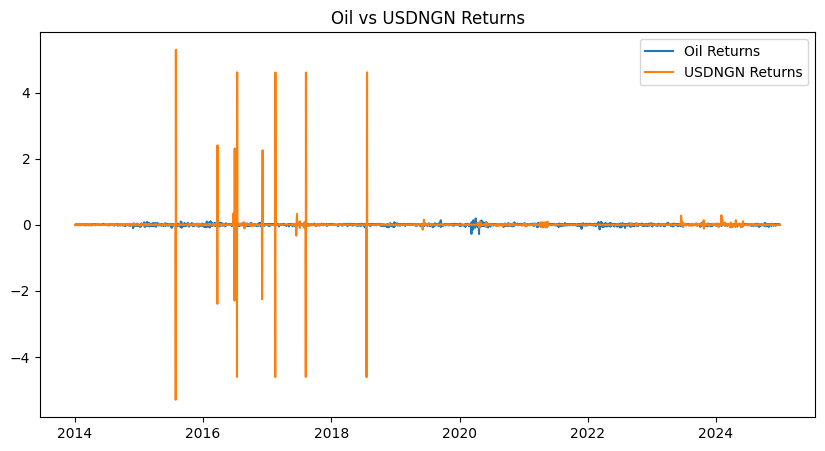

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(merged["Date"], merged["Oil_Return"], label="Oil Returns")
plt.plot(merged["Date"], merged["USDNGN_Return"], label="USDNGN Returns")
plt.legend()
plt.title("Oil vs USDNGN Returns")
plt.savefig("oil vs usd_ngn returns")
plt.show()


In [37]:
merged["USDNGN_Return"].describe()

count    2760.000000
mean        0.000754
std         0.306400
min        -5.292802
25%        -0.001678
50%         0.000000
75%         0.002436
max         5.292299
Name: USDNGN_Return, dtype: float64

In [38]:
print(merged[["Oil_Return", "USDNGN_Return"]].corr())

               Oil_Return  USDNGN_Return
Oil_Return        1.00000       -0.03048
USDNGN_Return    -0.03048        1.00000


In [39]:
merged.to_csv(r"C:\Users\USER\OneDrive\Documents\oil-usd-ngn-bank-returns-analysis\data/merged_data.csv", index=False)

In [40]:
merged.loc[merged["USDNGN_Return"].abs() > 1]

,Date,Close_Oil,High_Oil,Low_Oil,Open_Oil,Volume_Oil,Oil_Return,Close_USD,High_USD,Low_USD,Open_USD,Volume_USD,USDNGN_Return
392,2015-07-29,53.380001,54.320000,52.520000,53.009998,46631,0.001500,1.000000,198.850006,195.910004,195.910004,0,-5.292802
393,2015-07-30,53.310001,54.360001,53.029999,53.560001,33368,-0.001312,198.800003,198.850006,196.479996,196.479996,0,5.292299
555,2016-03-22,41.790001,42.119999,40.980000,41.509998,31640,0.006000,18.000000,199.000000,196.500000,196.880005,0,-2.390952
556,2016-03-23,40.470001,41.810001,40.400002,41.570000,30553,-0.032096,199.000000,197.160004,196.500000,196.690002,0,2.402933
623,2016-06-28,48.580002,48.759998,47.470001,47.549999,22475,0.029666,28.000000,282.000000,279.730011,280.010010,0,-2.291271
624,2016-06-29,50.610001,50.720001,48.639999,48.919998,13050,0.040937,281.000000,280.170013,279.649994,280.170013,0,2.306150
632,2016-07-12,48.470001,48.560001,46.119999,46.200001,32157,0.046884,2.800000,282.000000,279.859985,279.859985,0,-4.602989
633,2016-07-13,46.259998,48.200001,46.090000,48.040001,29323,-0.046667,281.589996,282.000000,280.140015,281.709991,0,4.610833
731,2016-12-02,54.459999,54.500000,52.860001,53.869999,39305,0.076286,33.000000,315.000000,314.000000,315.000000,0,-2.252885
732,2016-12-05,54.939999,55.330002,53.810001,54.230000,33656,0.008775,314.000000,315.000000,314.500000,315.000000,0,2.252885


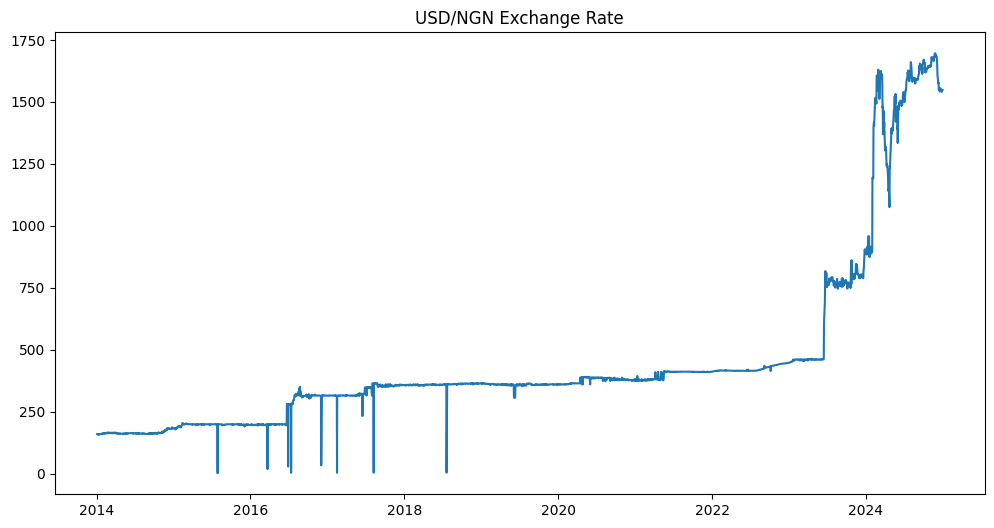

In [41]:
plt.figure(figsize=(12,6))
plt.plot(merged["Date"], merged["Close_USD"])
plt.title("USD/NGN Exchange Rate")
plt.savefig("USD_NGN Exchange Rate")
plt.show()

In [42]:
merged.loc[merged["Close_USD"] < 50]

,Date,Close_Oil,High_Oil,Low_Oil,Open_Oil,Volume_Oil,Oil_Return,Close_USD,High_USD,Low_USD,Open_USD,Volume_USD,USDNGN_Return
392,2015-07-29,53.380001,54.320000,52.520000,53.009998,46631,0.001500,1.00,198.850006,195.910004,195.910004,0,-5.292802
555,2016-03-22,41.790001,42.119999,40.980000,41.509998,31640,0.006000,18.00,199.000000,196.500000,196.880005,0,-2.390952
623,2016-06-28,48.580002,48.759998,47.470001,47.549999,22475,0.029666,28.00,282.000000,279.730011,280.010010,0,-2.291271
632,2016-07-12,48.470001,48.560001,46.119999,46.200001,32157,0.046884,2.80,282.000000,279.859985,279.859985,0,-4.602989
731,2016-12-02,54.459999,54.500000,52.860001,53.869999,39305,0.076286,33.00,315.000000,314.000000,315.000000,0,-2.252885
781,2017-02-15,55.750000,56.250000,55.549999,55.840000,26608,-0.003938,3.14,315.000000,314.000000,315.000000,0,-4.605170
900,2017-08-08,52.139999,52.730000,51.820000,52.240002,24795,-0.004401,3.62,365.000000,363.500000,365.000000,0,-4.602404
1138,2018-07-20,73.070000,73.470001,72.290001,72.589996,24861,0.006728,3.59,360.730011,359.429993,359.429993,0,-4.609340


In [43]:
merged = merged.sort_values("Date")

merged["Oil_Return"] = np.log(merged["Close_Oil"] / merged["Close_Oil"].shift(1))
merged["USDNGN_Return"] = np.log(merged["Close_USD"] / merged["Close_USD"].shift(1))

merged = merged.dropna()

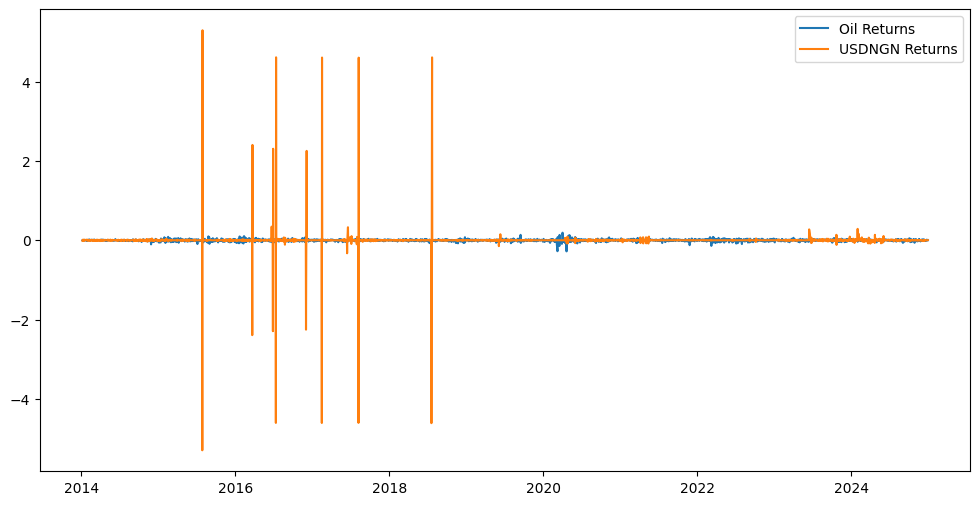

In [44]:
plt.figure(figsize=(12,6))
plt.plot(merged["Date"], merged["Oil_Return"], label="Oil Returns")
plt.plot(merged["Date"], merged["USDNGN_Return"], label="USDNGN Returns")
plt.legend()
plt.show()

In [45]:
merged.loc[merged["Close_USD"] < 50]

,Date,Close_Oil,High_Oil,Low_Oil,Open_Oil,Volume_Oil,Oil_Return,Close_USD,High_USD,Low_USD,Open_USD,Volume_USD,USDNGN_Return
392,2015-07-29,53.380001,54.320000,52.520000,53.009998,46631,0.001500,1.00,198.850006,195.910004,195.910004,0,-5.292802
555,2016-03-22,41.790001,42.119999,40.980000,41.509998,31640,0.006000,18.00,199.000000,196.500000,196.880005,0,-2.390952
623,2016-06-28,48.580002,48.759998,47.470001,47.549999,22475,0.029666,28.00,282.000000,279.730011,280.010010,0,-2.291271
632,2016-07-12,48.470001,48.560001,46.119999,46.200001,32157,0.046884,2.80,282.000000,279.859985,279.859985,0,-4.602989
731,2016-12-02,54.459999,54.500000,52.860001,53.869999,39305,0.076286,33.00,315.000000,314.000000,315.000000,0,-2.252885
781,2017-02-15,55.750000,56.250000,55.549999,55.840000,26608,-0.003938,3.14,315.000000,314.000000,315.000000,0,-4.605170
900,2017-08-08,52.139999,52.730000,51.820000,52.240002,24795,-0.004401,3.62,365.000000,363.500000,365.000000,0,-4.602404
1138,2018-07-20,73.070000,73.470001,72.290001,72.589996,24861,0.006728,3.59,360.730011,359.429993,359.429993,0,-4.609340


In [46]:
print(merged["Close_USD"].min())
print(merged.nsmallest(10, "Close_USD"))

1.0
           Date   Close_Oil    High_Oil     Low_Oil    Open_Oil  Volume_Oil  \
392  2015-07-29   53.380001   54.320000   52.520000   53.009998       46631   
632  2016-07-12   48.470001   48.560001   46.119999   46.200001       32157   
781  2017-02-15   55.750000   56.250000   55.549999   55.840000       26608   
1138 2018-07-20   73.070000   73.470001   72.290001   72.589996       24861   
900  2017-08-08   52.139999   52.730000   51.820000   52.240002       24795   
555  2016-03-22   41.790001   42.119999   40.980000   41.509998       31640   
623  2016-06-28   48.580002   48.759998   47.470001   47.549999       22475   
731  2016-12-02   54.459999   54.500000   52.860001   53.869999       39305   
6    2014-01-13  106.750000  107.769997  106.519997  107.639999        3669   
1    2014-01-06  106.730003  107.949997  106.580002  107.040001        7015   

      Oil_Return   Close_USD    High_USD     Low_USD    Open_USD  Volume_USD  \
392     0.001500    1.000000  198.850006  195.

In [47]:
merged = merged[
    (merged["Close_USD"] > 100) &
    (merged["Close_Oil"] > 10)
]

In [48]:

merged = merged.sort_values("Date")

merged["Oil_Return"] = np.log(
    merged["Close_Oil"] / merged["Close_Oil"].shift(1)
)

merged["USDNGN_Return"] = np.log(
    merged["Close_USD"] / merged["Close_USD"].shift(1)
)

merged = merged.dropna()

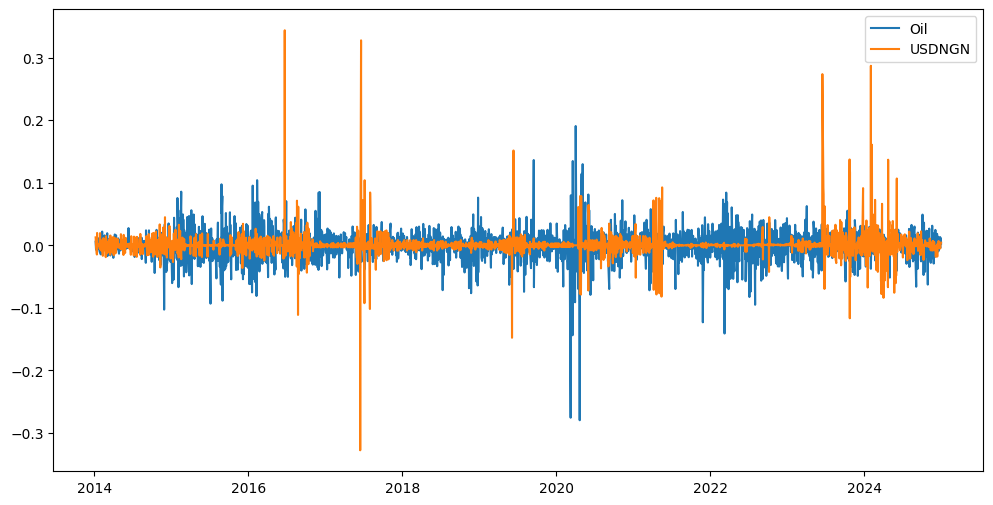

In [49]:
plt.figure(figsize=(12,6))
plt.plot(merged["Date"], merged["Oil_Return"], label="Oil")
plt.plot(merged["Date"], merged["USDNGN_Return"], label="USDNGN")
plt.legend()
plt.show()

In [50]:
merged.loc[abs(merged["USDNGN_Return"]) > 0.25]

,Date,Close_Oil,High_Oil,Low_Oil,Open_Oil,Volume_Oil,Oil_Return,Close_USD,High_USD,Low_USD,Open_USD,Volume_USD,USDNGN_Return
619,2016-06-22,49.880001,51.230000,49.189999,50.970001,34368,-0.014727,280.679993,280.829987,199.0,280.799988,0,0.343910
864,2017-06-15,46.919998,47.189999,46.700001,46.990002,26749,-0.001704,232.000000,321.000000,321.0,321.000000,0,-0.327814
866,2017-06-19,46.910000,47.750000,46.770000,47.299999,19703,-0.009758,322.000000,322.000000,320.0,322.000000,0,0.327814
2372,2023-06-16,76.610001,76.739998,75.080002,75.580002,20871,0.012346,608.000000,657.000000,600.0,620.000000,0,0.273788
2530,2024-02-01,78.699997,81.550003,78.580002,80.669998,48919,-0.037533,1194.000000,1194.000000,1192.0,1194.000000,0,0.287124


In [51]:
spikes = merged.loc[abs(merged["USDNGN_Return"]) > 0.25]
print(spikes[["Date", "Close_USD", "USDNGN_Return"]])

           Date    Close_USD  USDNGN_Return
619  2016-06-22   280.679993       0.343910
864  2017-06-15   232.000000      -0.327814
866  2017-06-19   322.000000       0.327814
2372 2023-06-16   608.000000       0.273788
2530 2024-02-01  1194.000000       0.287124


In [52]:
merged = merged[abs(merged["USDNGN_Return"]) < 0.5]
merged = merged[abs(merged["Oil_Return"]) < 0.5]

In [53]:

merged = merged.sort_values("Date")

merged["Oil_Return"] = np.log(
    merged["Close_Oil"] / merged["Close_Oil"].shift(1)
)

merged["USDNGN_Return"] = np.log(
    merged["Close_USD"] / merged["Close_USD"].shift(1)
)

merged = merged.dropna()

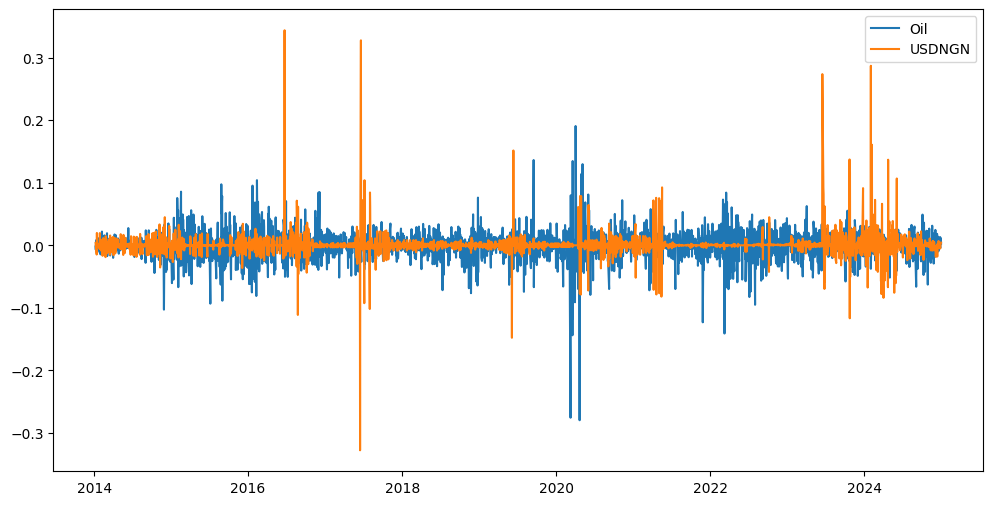

In [54]:
plt.figure(figsize=(12,6))
plt.plot(merged["Date"], merged["Oil_Return"], label="Oil")
plt.plot(merged["Date"], merged["USDNGN_Return"], label="USDNGN")
plt.legend()
plt.show()

In [55]:
merged.loc[615:870, ["Date", "Close_USD"]]

,Date,Close_USD
615,2016-06-16,194.699997
616,2016-06-17,198.800003
617,2016-06-20,195.059998
618,2016-06-21,199.000000
619,2016-06-22,280.679993
...,...,...
866,2017-06-19,322.000000
867,2017-06-20,320.000000
868,2017-06-21,321.000000
869,2017-06-22,320.000000


In [56]:
merged[["Oil_Return", "USDNGN_Return"]].corr()

,Oil_Return,USDNGN_Return
Oil_Return,1.00000,-0.01489
USDNGN_Return,-0.01489,1.00000


In [57]:
merged["Month"] = merged["Date"].dt.to_period("M")

monthly = merged.groupby("Month")[["Oil_Return","USDNGN_Return"]].sum()

monthly.corr()

,Oil_Return,USDNGN_Return
Oil_Return,1.000,-0.025
USDNGN_Return,-0.025,1.000


In [58]:
merged["Oil_lag1"] = merged["Oil_Return"].shift(1)

merged[["Oil_lag1","USDNGN_Return"]].corr()

,Oil_lag1,USDNGN_Return
Oil_lag1,1.00000,0.01882
USDNGN_Return,0.01882,1.00000
